In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "stsb"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 5749
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'A plane is taking off.',
 'sentence2': 'An air plane is taking off.',
 'label': 5.0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1']

'Some men are fighting.'

In [11]:
raw_train_dataset[5]['sentence2']

'Two men are fighting.'

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': Value('float32'),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1379
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 66]),
 'token_type_ids': torch.Size([32, 66]),
 'attention_mask': torch.Size([32, 66])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
num_labels = 1

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(4.9161, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(10.6868, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [28]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda')

### Load Trained Weights

In [29]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

In [32]:
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [33]:
eval_loop(model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

# 5. Top Layer Drop

In [34]:
from layer_drop import layer_drop

In [35]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [36]:
init_metric = eval_loop(model, val_dataloader, task_name, device, regression=True)[0]
init_metric

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

In [37]:
performance_track = layer_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9,
    cka_evaluator=cka_eval, teacher_model=teacher_model, drop_strategy="contribution", cka_max_iter=115,
    regression=True
)

Target Metric for stsb: pearson
Original pearson score: 0.9001
Recovery threshold: 0.0090

Merge Iteration: 1/9


CKA Evaluation: 100%|██████████| 115/115 [01:07<00:00,  1.71it/s]


  Similarity Stats:
    Average: 0.590880
    Highest: 0.634851
    Lowest:  0.349979
Drop Layer: 8
Number of Layers Remaining: 11
  Metrics:
    ★ pearson: 0.8965
      spearmanr: 0.8934
  Performance drop: 0.0036 (threshold: 0.0090)
  → Recovery training NOT needed
  • 11 layers (not in target list, skipping save)
Merge Iteration: 2/9


CKA Evaluation: 100%|██████████| 115/115 [00:57<00:00,  2.01it/s]


  Similarity Stats:
    Average: 0.586203
    Highest: 0.633661
    Lowest:  0.350298
Drop Layer: 7
Number of Layers Remaining: 10
  Metrics:
    ★ pearson: 0.8936
      spearmanr: 0.8908
  Performance drop: 0.0065 (threshold: 0.0090)
  → Recovery training NOT needed
  • 10 layers (not in target list, skipping save)
Merge Iteration: 3/9


...

Training:  90%|█████████ | 1620/1800 [06:56<00:29,  6.10it/s]

✓ Saved checkpoint (best loss: 1.1027)

<----------------- Epoch 9 ----------------->
Loss: 0.13, Training Metrics:
  pearson: 0.9383
  spearmanr: 0.9284
Validation Loss: 1.1, Validation Metrics:
  pearson: 0.8093
  spearmanr: 0.8112
Elapsed Time: 42.7434 sec


Training: 100%|██████████| 1800/1800 [07:52<00:00,  3.81it/s]


<----------------- Epoch 10 ----------------->
Loss: 0.13, Training Metrics:
  pearson: 0.9371
  spearmanr: 0.9265
Validation Loss: 1.13, Validation Metrics:
  pearson: 0.8090
  spearmanr: 0.8112
Elapsed Time: 47.5861 sec

Total Training Time: 472.44 sec
Chosen Primary Metric: pearson
Best Metric Run: 0.8093

  → Loading best checkpoint...


  ✓ Loaded best checkpoint from epoch 9
    Best val loss: 1.1027
    Best val metrics: {'pearson': 0.8093365067711502, 'spearmanr': 0.8111535448298179}
  ✓ Cleaned up temporary checkpoint
  ✓ Saved 3-layer model to ./weights/contribution/layer-3-stsb.pt


In [38]:
performance_track

{'performance_track': [{'pearson': 0.900084701022039,
   'spearmanr': 0.8962584593578651},
  {'pearson': 0.8965288611503173, 'spearmanr': 0.8933766531011987},
  {'pearson': 0.8935627953301559, 'spearmanr': 0.8908161299841173},
  {'pearson': 0.8943909230003049, 'spearmanr': 0.8904388699376246},
  {'pearson': 0.8905725617698402, 'spearmanr': 0.8855740783284766},
  {'pearson': 0.8896400208253695, 'spearmanr': 0.8850317646844574},
  {'pearson': 0.8821412747431225, 'spearmanr': 0.8776908985179931},
  {'pearson': 0.8747440056487834, 'spearmanr': 0.8709279116503895},
  {'pearson': 0.8565102667906294, 'spearmanr': 0.8539233020656735},
  {'pearson': 0.8093365067711502, 'spearmanr': 0.8111535448298179}],
 'remaining_layers': [[2, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 9, 10, 11],
  [0, 1, 2, 3, 4, 9, 10, 11],
  [0, 1, 2, 3, 4, 10, 11],
  [0, 2, 3, 4, 10, 11],
  [0, 2, 3, 10, 11],
  [0, 2, 10, 11],
  [2, 10, 11]]}

In [39]:
torch.save(performance_track, f'./weights/contribution/performance_track_{task_name}.pt')

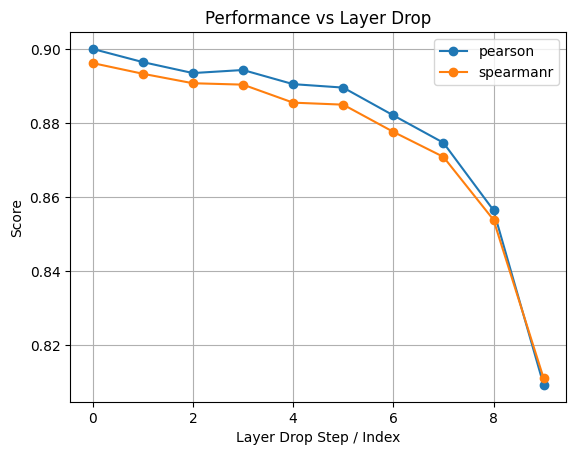

In [40]:
import matplotlib.pyplot as plt

performance_track = performance_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()